Found 2 CSV files in 'objectives' folder:
 - ../objectives/SimpleHeuristic_a_1.csv
 - ../objectives/SimpleHeuristic_a_5.csv


,instance_index,SimpleHeuristic_a_1,SimpleHeuristic_a_5
0,0,0.586207,0.586207
1,1,0.060606,0.062952
2,2,0.846774,0.853226
3,3,0.439560,0.437363
4,4,27.298137,27.295652
5,5,21.152174,21.152174
6,6,21.372222,21.372222
7,7,16.904762,16.902381
8,8,0.500000,0.501974
9,9,4.558747,4.558747


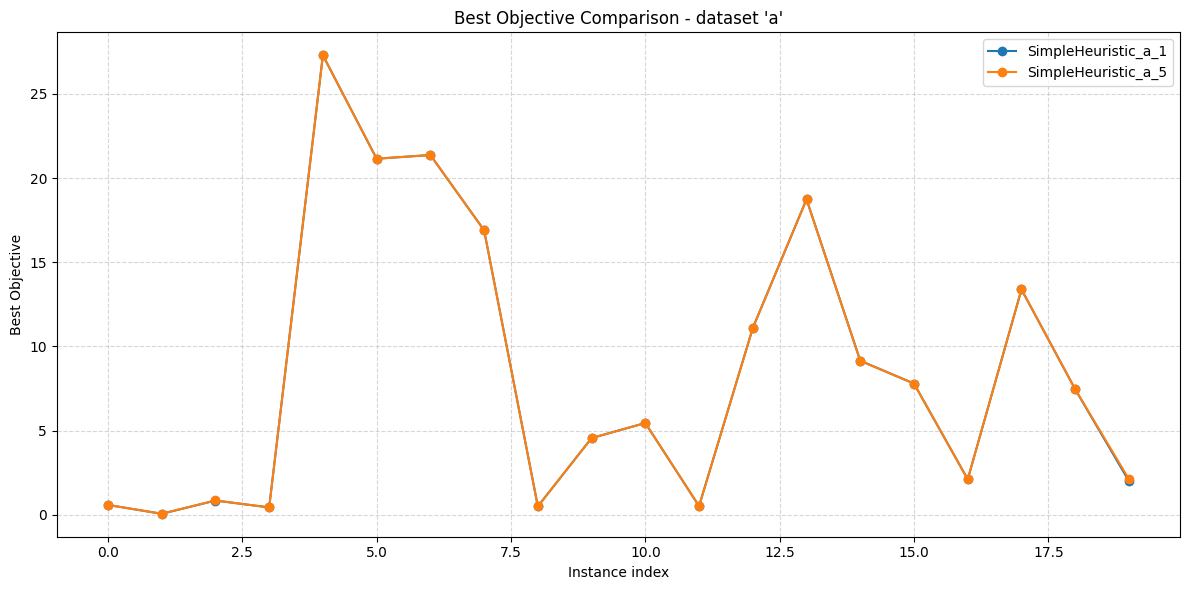

In [8]:
import argparse
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def build_objective_comparison_table(csv_paths: list[str], dataset: str) -> pd.DataFrame:
    """Build a wide table comparing best_objective values across CSV files."""
    series_by_method: dict[str, pd.Series] = {}

    for path in csv_paths:
        df = pd.read_csv(path)
        df_filtered = df[df["dataset"] == dataset].reset_index(drop=True)

        if df_filtered.empty:
            print(f"Warning: no rows with dataset='{dataset}' in {path}, skipping.")
            continue

        label = os.path.splitext(os.path.basename(path))[0]
        series_by_method[label] = pd.Series(df_filtered["best_objective"].values, name=label)

    if not series_by_method:
        return pd.DataFrame()

    comparison = pd.DataFrame(series_by_method)
    comparison.index.name = "instance_index"
    return comparison.reset_index()


def plot_best_objectives(comparison: pd.DataFrame, dataset: str) -> None:
    """Plot comparison lines from a prebuilt comparison DataFrame."""
    if comparison.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 6))
    x = comparison["instance_index"].values

    for column in comparison.columns[1:]:
        plt.plot(x, comparison[column].values, marker="o", label=column)

    plt.title(f"Best Objective Comparison - dataset '{dataset}'")
    plt.xlabel("Instance index")
    plt.ylabel("Best Objective")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_objective_table(comparison: pd.DataFrame, dataset: str) -> None:
    """Render a matplotlib table with objective values for each method."""
    if comparison.empty:
        print("No data to show in table.")
        return

    table_data = comparison.copy()
    
    for column in table_data.columns[1:]:
        table_data[column] = table_data[column].map(
            lambda value: f"{value:.3f}" if pd.notna(value) else ""
        )

    fig_height = max(4, 0.35 * len(table_data) + 1.5)
    fig_width = max(8, 2.2 * len(table_data.columns))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=table_data.values,
        colLabels=table_data.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)

    plt.title(f"Objective Values Table - dataset '{dataset}'", pad=16)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Compare best_objective values across multiple CSV files."
    )

    # parser.add_argument(
    #     "csv_files",
    #     nargs="+",
    #     help="Paths to CSV files (must contain 'dataset' and 'best_objective' columns).",
    # )

    # parser.add_argument(
    #     "--dataset",
    #     required=True,
    #     help="Dataset name to filter rows by.",
    # )

    folder = "../objectives"
    csv_files = [f for f in Path(folder).iterdir() if f.is_file()]
    
    print(f"Found {len(csv_files)} CSV files in 'objectives' folder:")
    for path in csv_files:
        print(f" - {path}")

    dataset = "a"

    # args = parser.parse_args()
    comparison_table = build_objective_comparison_table(csv_files, dataset)
    display(comparison_table)
    plot_best_objectives(comparison_table, dataset)
    # plot_objective_table(comparison_table, dataset)
